In [11]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import ast
import json
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 18,
})

save = 0

project_root = Path.cwd()
if not (project_root / "experiments").exists() and (project_root.parent / "experiments").exists():
    project_root = project_root.parent
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [12]:
project_root = Path.cwd()
if not (project_root / "experiments").exists():
    project_root = project_root.parent

results_dir = project_root / "experiments" / "technology diffusion"
if not results_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {results_dir}")

result_csv_files = sorted(results_dir.glob("technology_diffusion_results__*.csv"))
if not result_csv_files:
    fallback = results_dir / "technology_diffusion_results.csv"
    if fallback.exists():
        result_csv_files = [fallback]

if not result_csv_files:
    raise FileNotFoundError("No technology_diffusion_results CSV files were found.")

frames = []
for file in result_csv_files:
    df = pd.read_csv(file)
    df["source_file"] = file.name
    frames.append(df)

df_results = pd.concat(frames, ignore_index=True)

for col in ["n_nodes", "c", "seed", "total_time", "K"]:
    if col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col], errors="coerce")

print(f"Loaded {len(result_csv_files)} files and {len(df_results)} total rows from {results_dir}.")
df_results.head()

Loaded 10 files and 1600 total rows from /Users/matteobergamaschi/Desktop/td_git/experiments/technology diffusion.


,algorithm,n_nodes,c,seed,total_time,K,history,source_file
0,betweenness,200,1,1,0.1501,39.0,"[[200, 0.0], [100, 0.029], [50, 0.0584], [39, ...",technology_diffusion_results__seed-1.csv
1,degree,200,1,1,0.0037,51.0,"[[200, 0.0], [100, 0.0007], [52, 0.0023], [51,...",technology_diffusion_results__seed-1.csv
2,degree_connected,200,1,1,0.0116,52.0,"[[200, 0.0], [100, 0.005], [52, 0.0083], [52, ...",technology_diffusion_results__seed-1.csv
3,degree_discount,200,1,1,0.0130,52.0,"[[200, 0.0], [100, 0.0041], [52, 0.0085], [52,...",technology_diffusion_results__seed-1.csv
4,degree_threshold,200,1,1,0.0144,23.0,"[[200, 0.0], [100, 0.0008], [50, 0.002], [25, ...",technology_diffusion_results__seed-1.csv


In [13]:
algorithm_order = [
    "degree_threshold",
    "degree_discount",
    "degree_connected",
    "degree",
    "betweenness",
    "goldberg_liu",
    "nads_binary_search",
]

plot_df = (
    df_results.groupby(["n_nodes", "algorithm"], as_index=False)
    .agg(mean_K=("K", "mean"), mean_total_time=("total_time", "mean"))
    .sort_values(["n_nodes", "algorithm"])
)

pivot_k = plot_df.pivot(index="n_nodes", columns="algorithm", values="mean_K").sort_index()
available_algorithms = [a for a in algorithm_order if a in pivot_k.columns]

if not available_algorithms:
    raise ValueError("No expected algorithms found in df_results.")

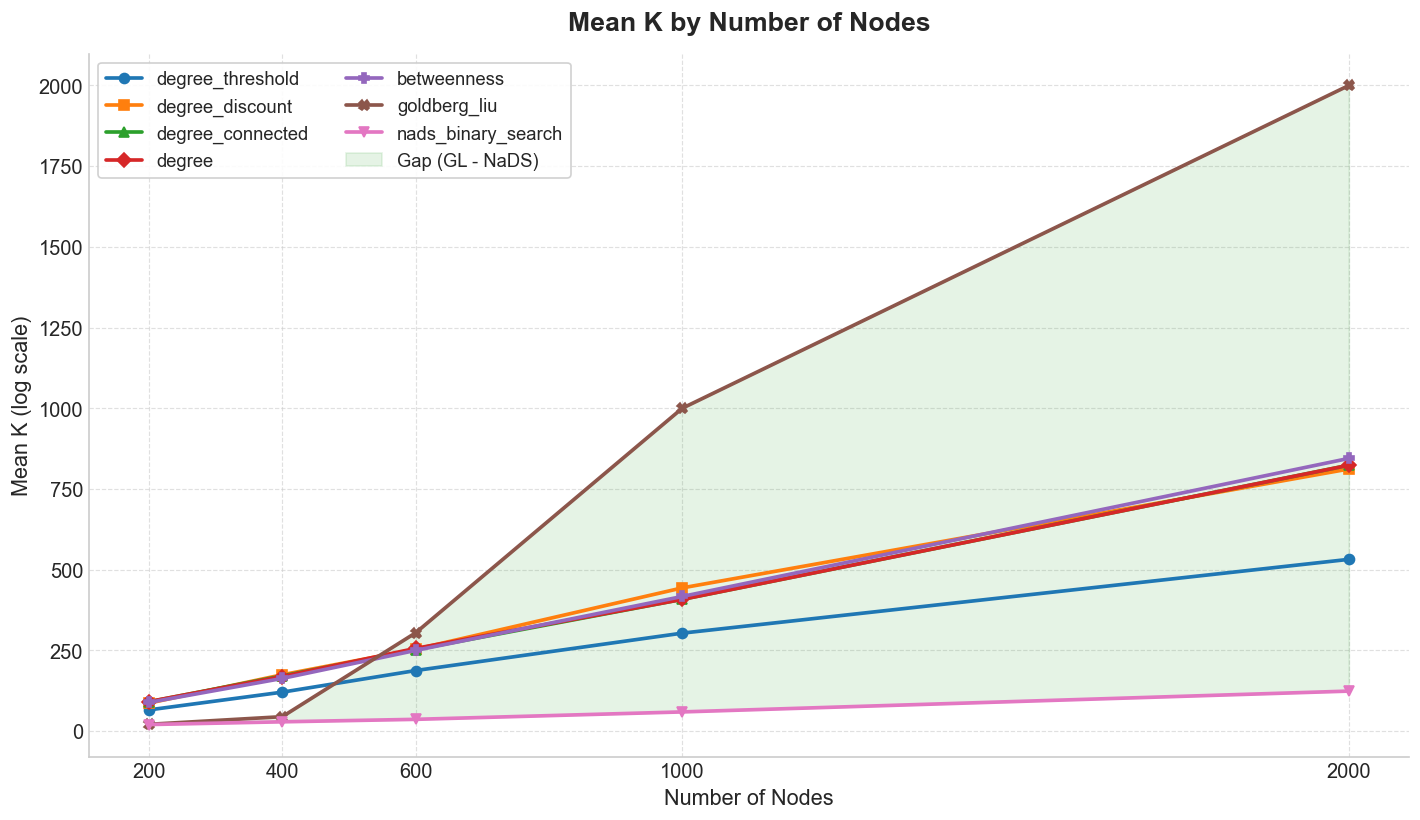

In [14]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

markers = ["o", "s", "^", "D", "P", "X", "v", "<"]
fallback_gl = pd.Series(pivot_k.index, index=pivot_k.index, dtype=float)

for i, alg in enumerate(available_algorithms):
    series = pivot_k[alg]
    if alg == "goldberg_liu":
        series = series.fillna(fallback_gl)

    ax.plot(
        pivot_k.index,
        series,
        marker=markers[i % len(markers)],
        linewidth=2.2,
        label=alg,
    )

if "goldberg_liu" in pivot_k.columns and "nads_binary_search" in pivot_k.columns:
    nads_series = pivot_k["nads_binary_search"]
    gl_series = pivot_k["goldberg_liu"].fillna(fallback_gl)
    ax.fill_between(
        pivot_k.index, nads_series, gl_series,
        where=(gl_series >= nads_series),
        interpolate=True,
        color="#2ca02c",
        alpha=0.12,
        label="Gap (GL - NaDS)",
    )

ax.set_title("Mean K by Number of Nodes", pad=14, weight="bold")
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Mean K (log scale)")
# ax.set_yscale("log")
ax.set_xticks(pivot_k.index.to_list())
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, framealpha=0.9, ncols=2, loc="best")

fig.tight_layout()
if save:
    fig.savefig(figures_dir / "mean_k_by_nodes.png", dpi=220, bbox_inches="tight")
plt.show()

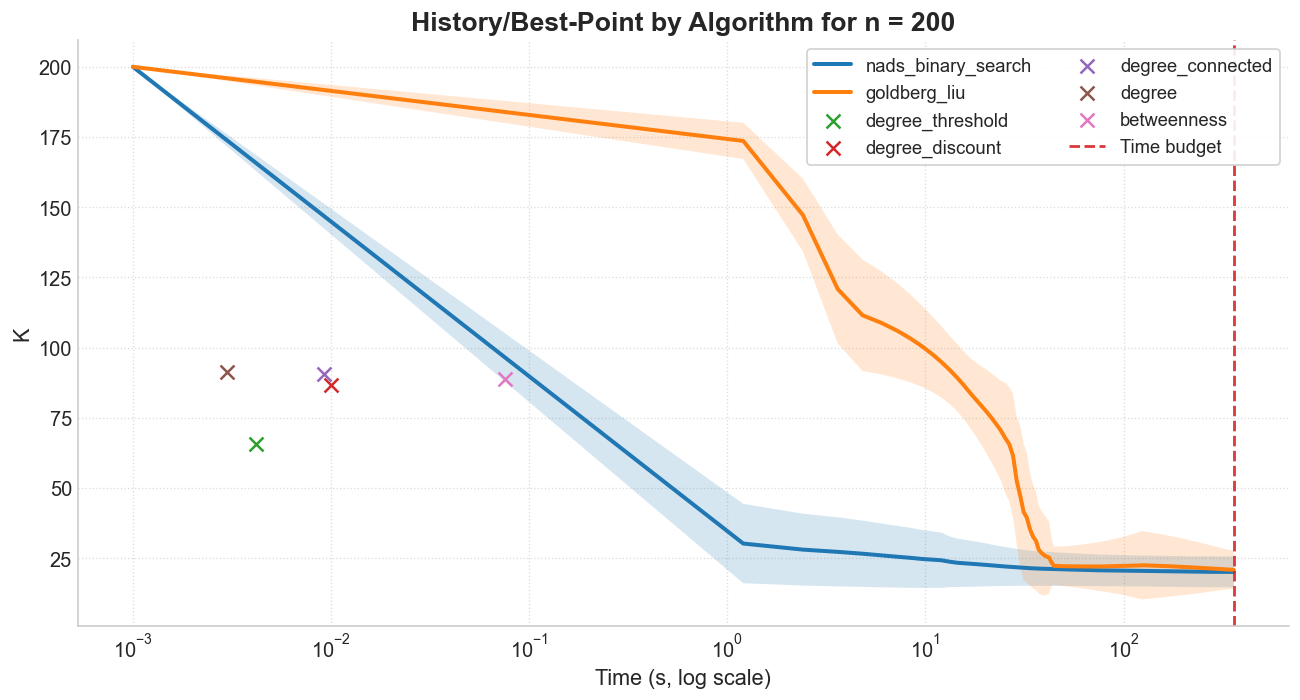

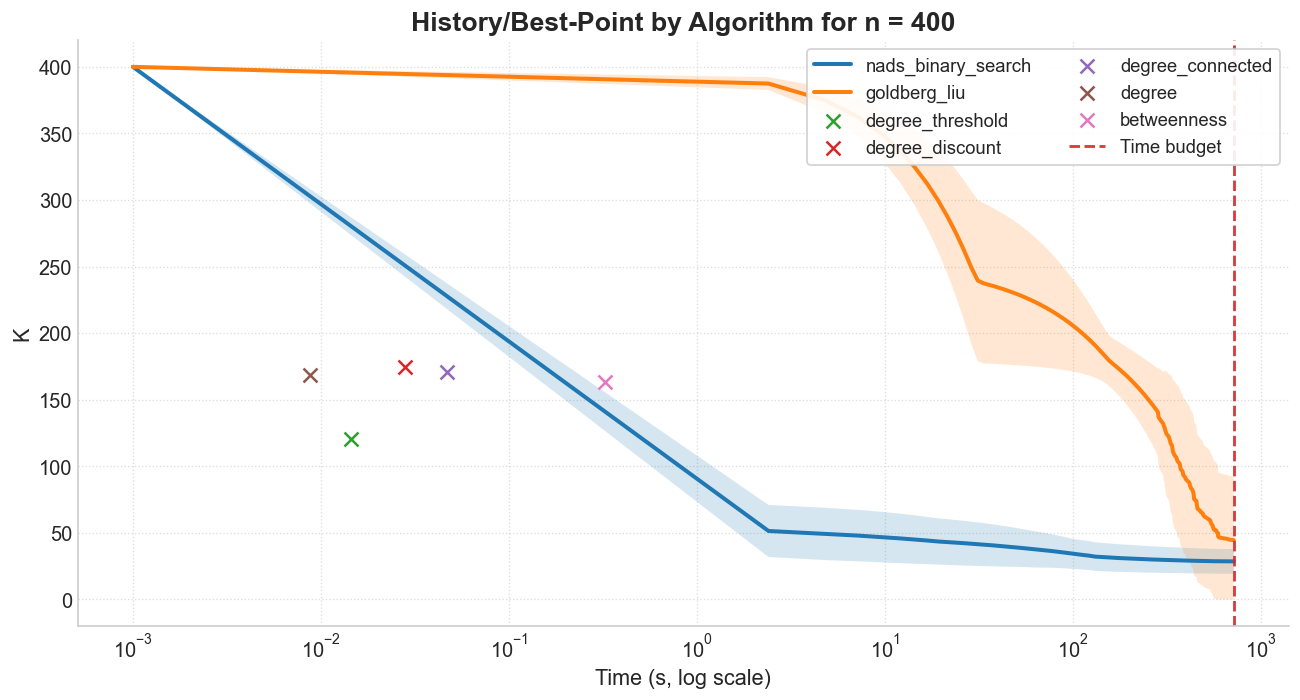

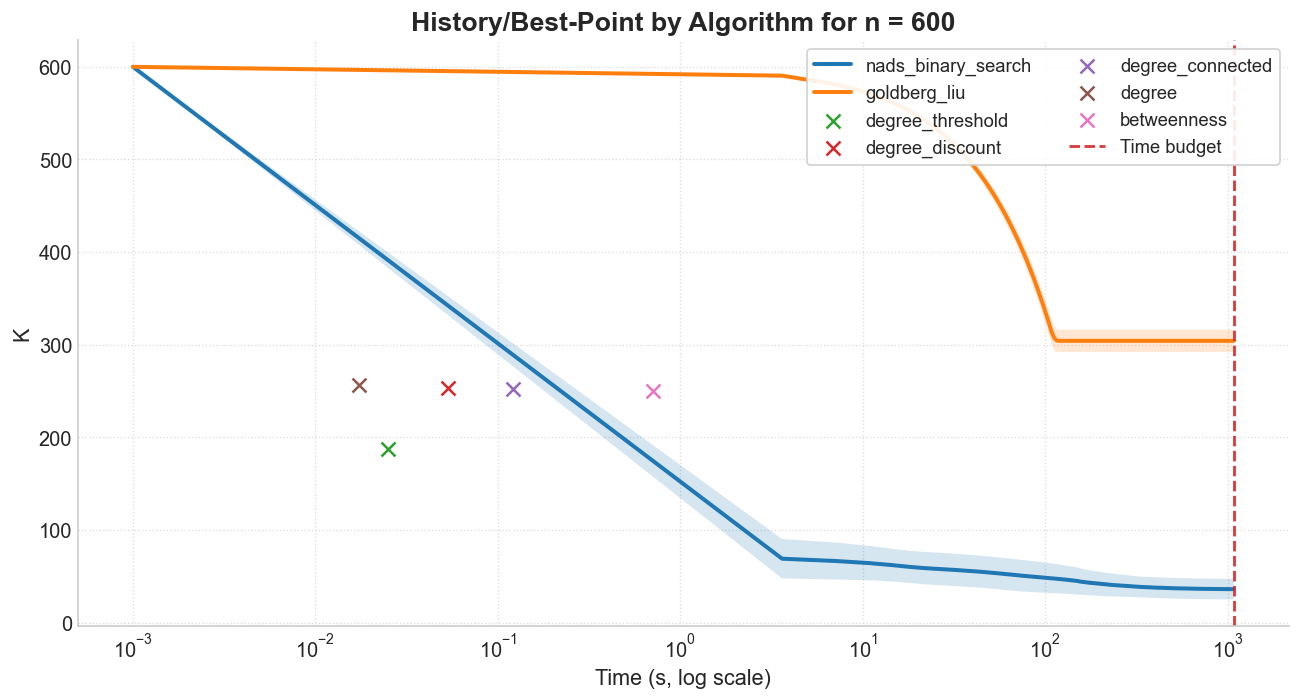

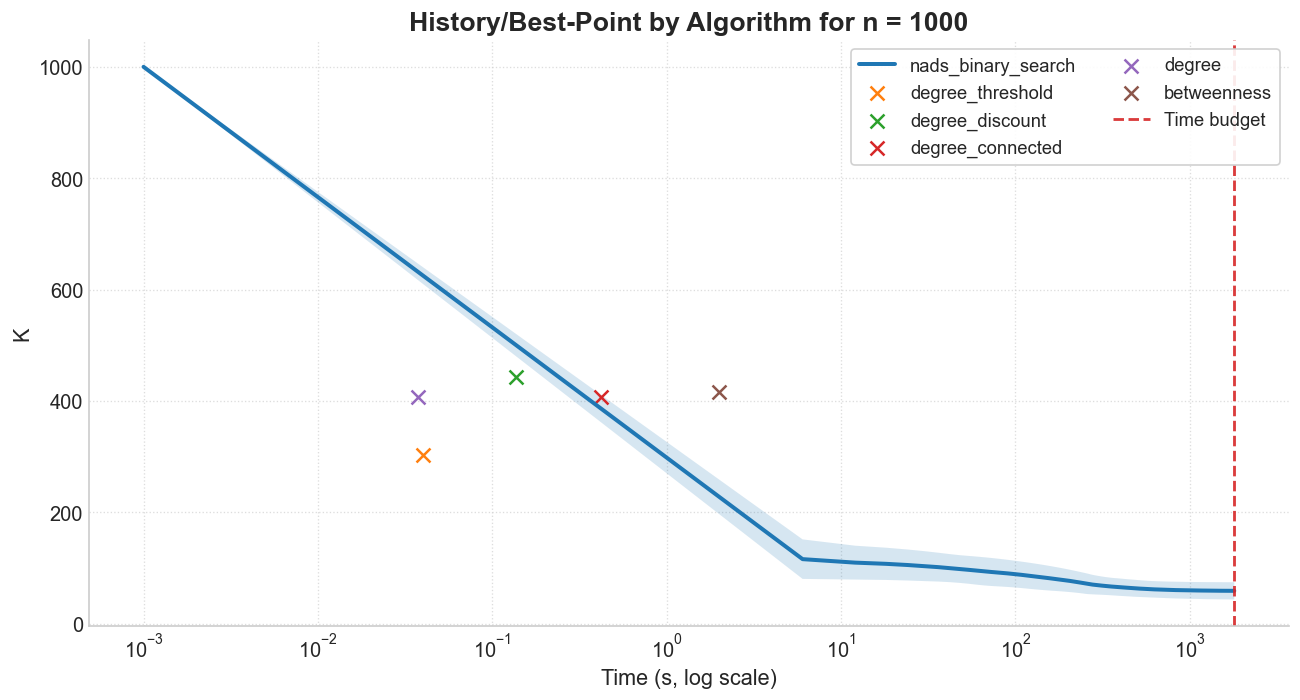

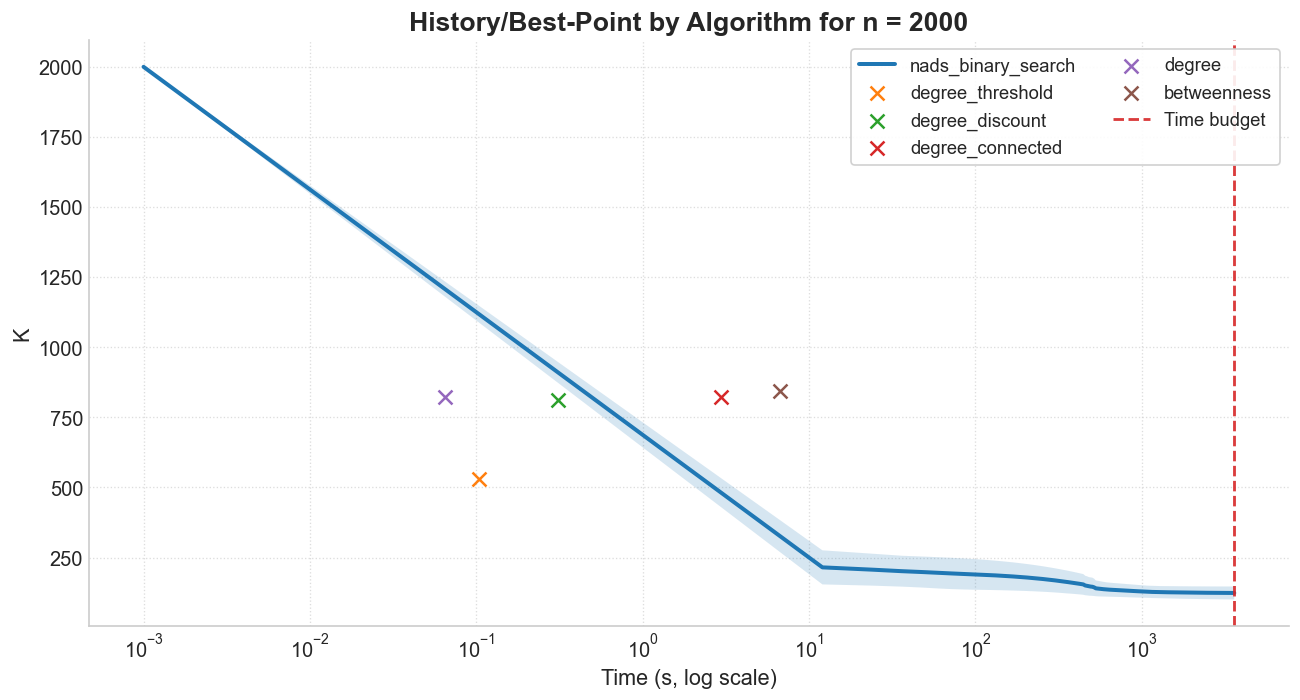

In [6]:
show_std_band = 1

def parse_history(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    if isinstance(raw, str):
        raw = raw.strip()
        if not raw:
            return None
        try:
            raw = json.loads(raw)
        except json.JSONDecodeError:
            raw = ast.literal_eval(raw)

    if not isinstance(raw, (list, tuple)) or len(raw) == 0:
        return None

    arr = np.asarray(raw, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return None

    times = arr[:, 1]
    values = arr[:, 0]
    order = np.argsort(times)
    return times[order], values[order]

def mean_std_curve(histories, t_end, n_points=300):
    parsed = [parse_history(h) for h in histories]
    parsed = [p for p in parsed if p is not None]
    if not parsed or t_end <= 0:
        return None

    t_grid = np.linspace(0.0, float(t_end), n_points)
    interp_values = []
    for t, v in parsed:
        t_unique, idx = np.unique(t, return_index=True)
        v_unique = v[idx]
        interp_values.append(np.interp(t_grid, t_unique, v_unique, right=v_unique[-1]))

    stacked = np.vstack(interp_values)
    return t_grid, stacked.mean(axis=0), stacked.std(axis=0)

def best_k_time_from_history(raw_history):
    parsed = parse_history(raw_history)
    if parsed is None:
        return None
    t_hist, k_hist = parsed
    best_k = float(np.min(k_hist))
    best_time = float(np.min(t_hist[k_hist == best_k]))
    return best_k, best_time

n_values = sorted(df_results["n_nodes"].dropna().unique())
if not n_values:
    raise ValueError("No n_nodes values found in df_results.")

curve_algorithms = [a for a in ["nads_binary_search", "goldberg_liu"] if a in available_algorithms]
point_algorithms = [
    a for a in available_algorithms
    if a not in set(curve_algorithms) and a != "high_thetas"
]

for n in n_values:
    df_n = df_results[df_results["n_nodes"] == n].copy()
    budget_s = (n / 100) * 180
    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

    plotted = 0
    for alg in curve_algorithms:
        histories = df_n.loc[df_n["algorithm"] == alg, "history"].tolist()
        curve = mean_std_curve(histories, t_end=budget_s)
        if curve is None:
            continue
        t_alg, y_mean, y_std = curve
        t_plot = np.maximum(t_alg, 1e-3)
        ax.plot(t_plot, y_mean, linewidth=2.4, label=alg)
        if show_std_band:
            ax.fill_between(
                t_plot,
                np.maximum(y_mean - y_std, 1e-9),
                y_mean + y_std,
                alpha=0.18,
            )
        plotted += 1

    for alg in point_algorithms:
        df_alg = df_n[df_n["algorithm"] == alg].copy()
        if df_alg.empty:
            continue

        best_points = []
        for _, row in df_alg.iterrows():
            point = best_k_time_from_history(row.get("history"))
            if point is None:
                k_fallback = pd.to_numeric(row.get("K"), errors="coerce")
                t_fallback = pd.to_numeric(row.get("total_time"), errors="coerce")
                if pd.notna(k_fallback) and pd.notna(t_fallback):
                    point = (float(k_fallback), float(t_fallback))
            if point is not None:
                best_points.append(point)

        if not best_points:
            continue

        mean_best_k = float(np.mean([p[0] for p in best_points]))
        mean_time_to_best = float(np.mean([p[1] for p in best_points]))

        x_point = max(mean_time_to_best, 1e-3)
        y_point = mean_best_k
        ax.scatter(x_point, y_point, s=70, marker="x", label=f"{alg}")
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        continue

    ax.axvline(
        budget_s,
        color="#d62728",
        linestyle="--",
        linewidth=1.7,
        alpha=0.9,
        label="Time budget",
    )

    ax.set_xscale("log")
    ax.set_title(f"History/Best-Point by Algorithm for n = {int(n)}", weight="bold")
    ax.set_xlabel("Time (s, log scale)")
    ax.set_ylabel("K")
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=True, framealpha=0.9, ncols=2)

    fig.tight_layout()
    if save:
        fig.savefig(figures_dir / f"mean_history_n_{int(n)}.png", dpi=220, bbox_inches="tight")
    plt.show()

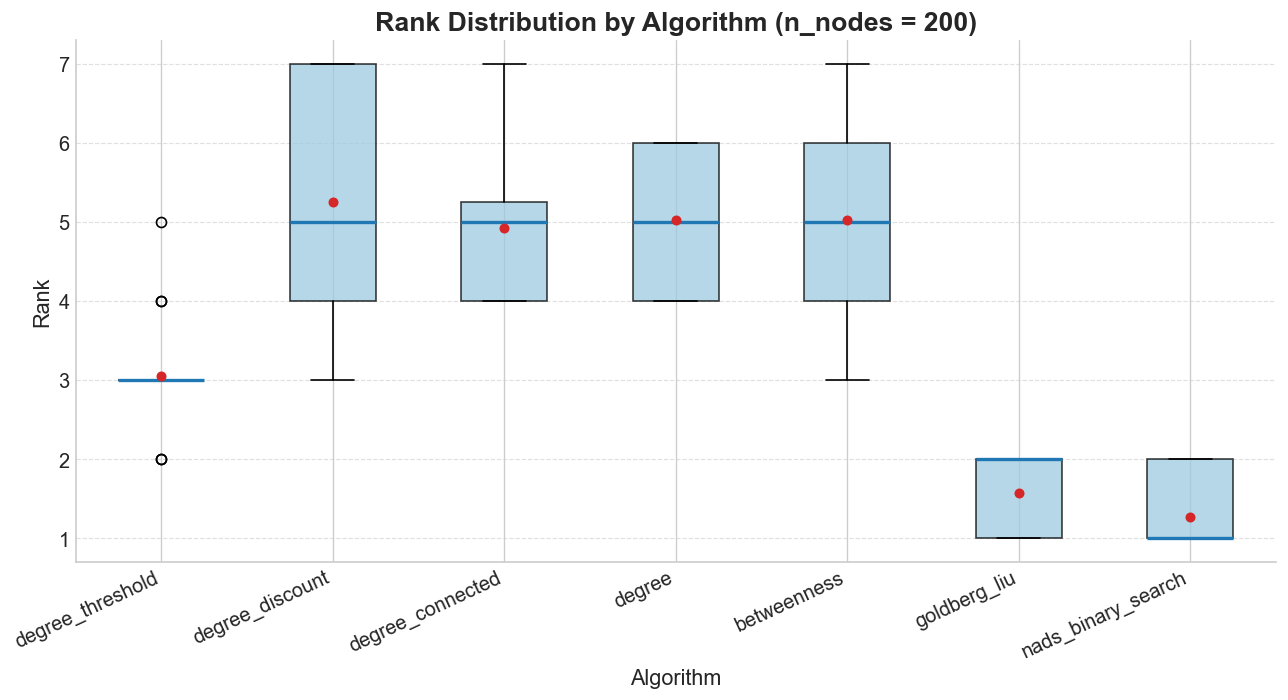

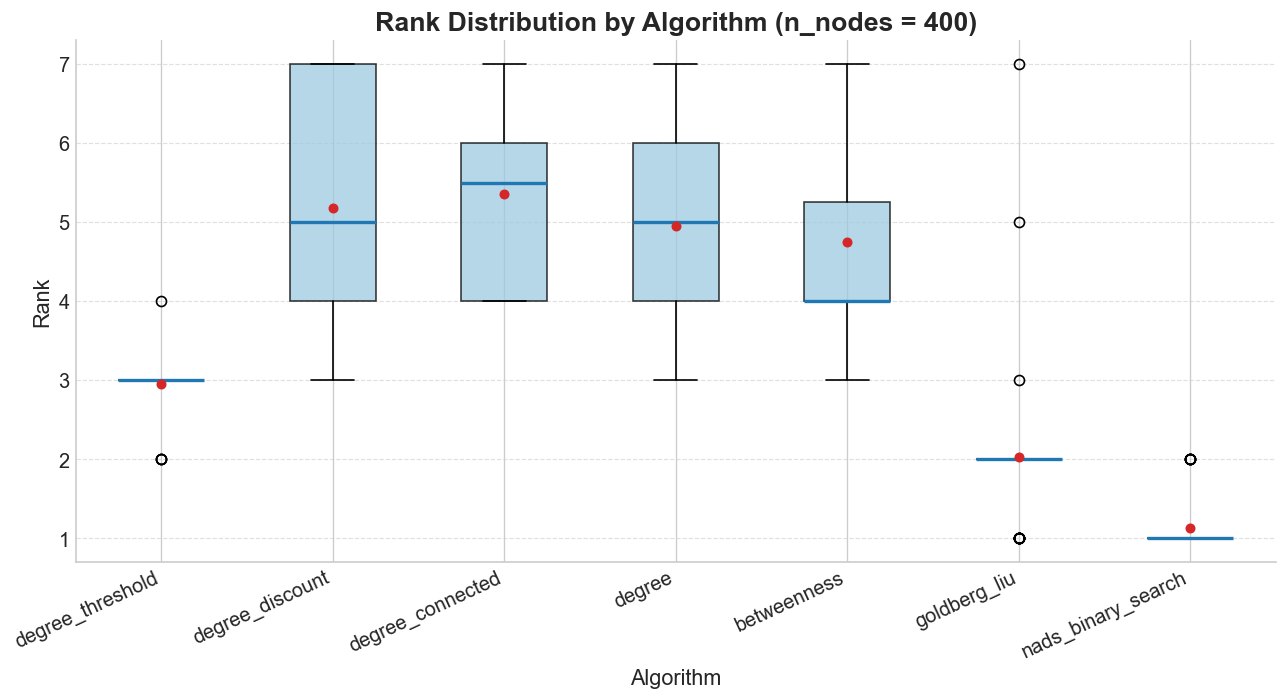

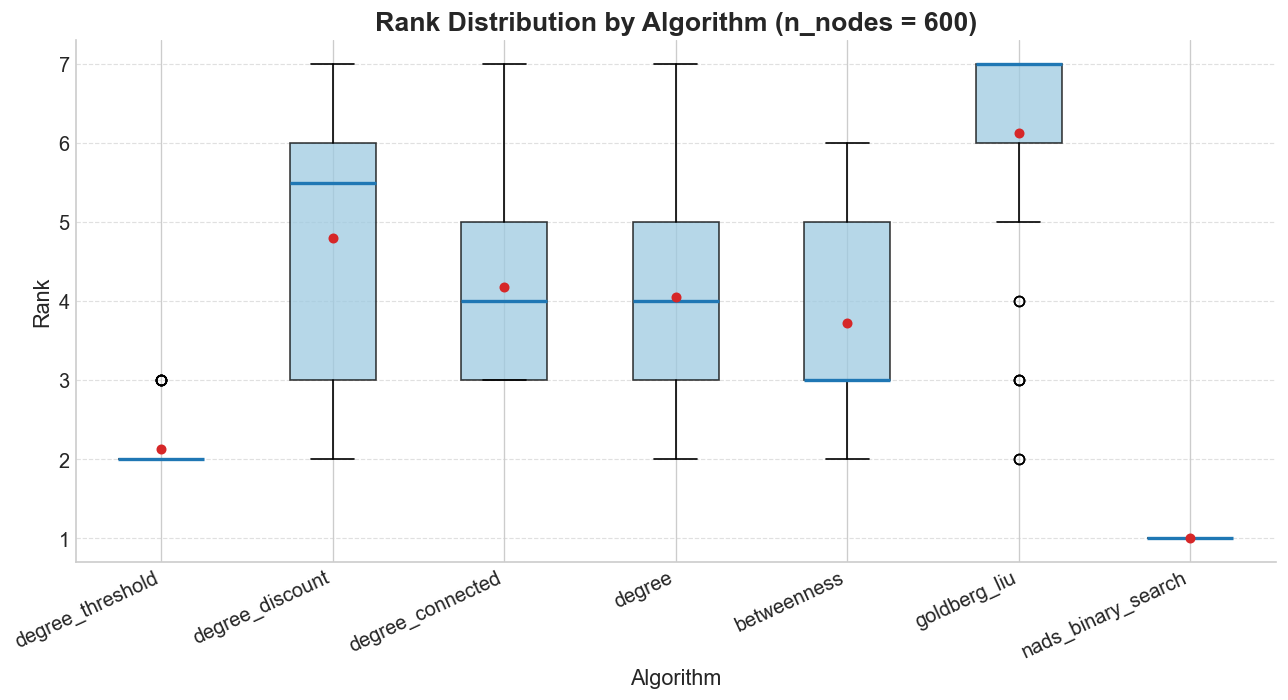

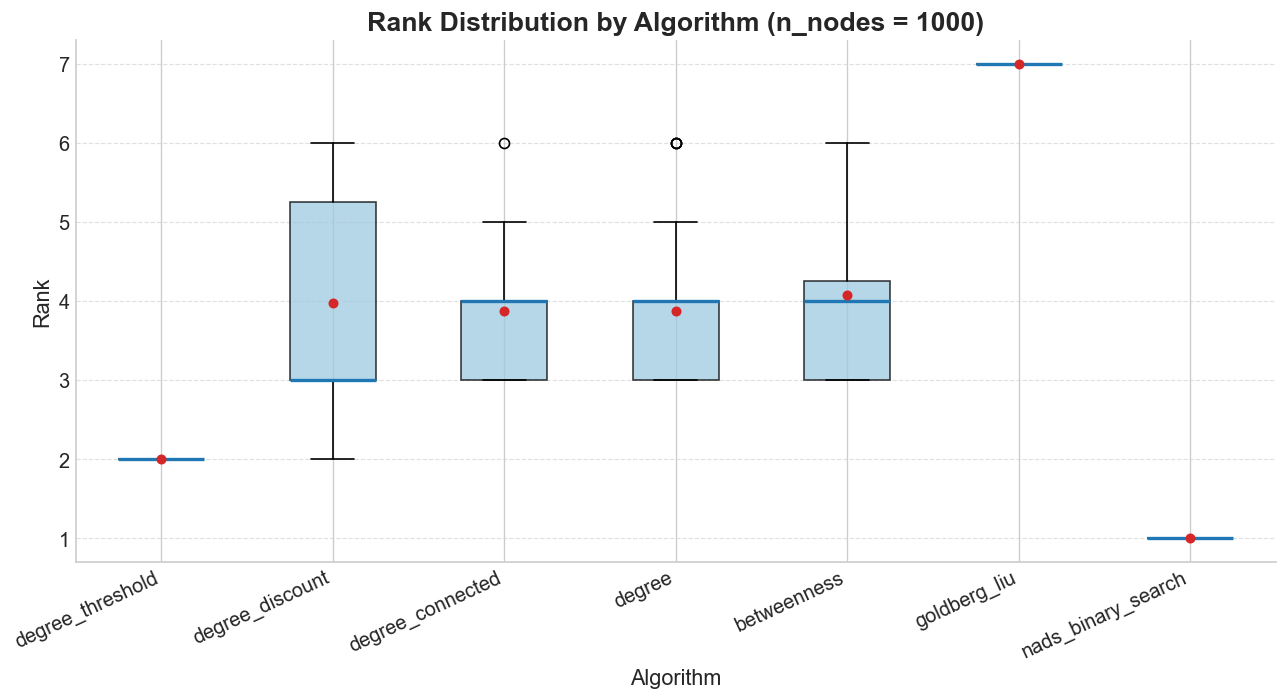

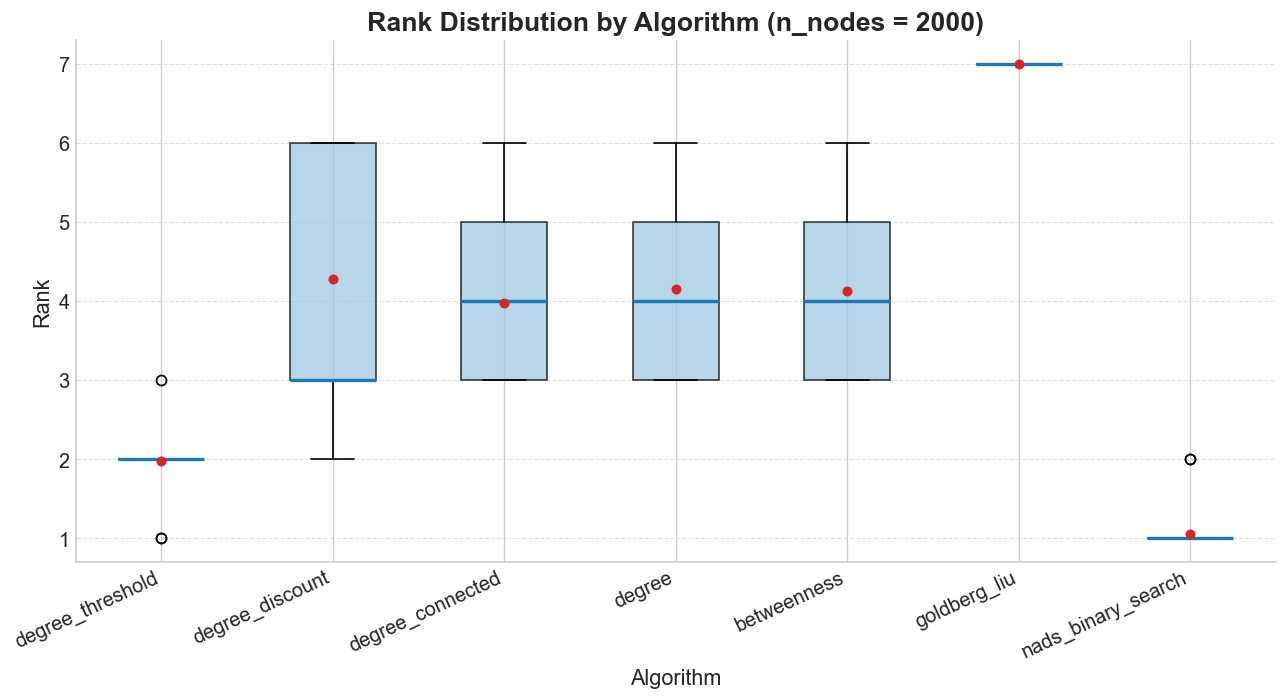

In [7]:
candidate_dims = ["n_nodes", "c", "seed"]
instance_keys = [col for col in candidate_dims if col in df_results.columns]

if "algorithm" not in df_results.columns or "K" not in df_results.columns:
    raise ValueError("df_results must contain at least 'algorithm' and 'K' columns.")
if "n_nodes" not in df_results.columns:
    raise ValueError("df_results must contain 'n_nodes' for this plot.")
if not instance_keys:
    raise ValueError("At least one of ['n_nodes', 'c', 'seed'] must be present in df_results.")

required_cols = instance_keys + ["algorithm"]
rank_source_first = df_results.dropna(subset=required_cols).copy()
rank_source_first = rank_source_first[rank_source_first["algorithm"] != "high_thetas"].copy()

rank_algorithms = [
    a for a in algorithm_order
    if a in rank_source_first["algorithm"].unique() and a != "high_thetas"
 ]
if not rank_algorithms:
    rank_algorithms = sorted(rank_source_first["algorithm"].dropna().unique())

instances = rank_source_first[instance_keys].drop_duplicates().copy()
instances["_k"] = 1
algorithms_df = pd.DataFrame({"algorithm": rank_algorithms, "_k": 1})

rank_complete = instances.merge(algorithms_df, on="_k", how="inner").drop(columns=["_k"])
k_values = rank_source_first[instance_keys + ["algorithm", "K"]].copy()
rank_complete = rank_complete.merge(k_values, on=instance_keys + ["algorithm"], how="left")

rank_complete["K_for_rank"] = rank_complete["K"].fillna(np.inf)
rank_complete["rank_in_instance"] = (
    rank_complete.groupby(instance_keys)["K_for_rank"]
    .rank(method="min", ascending=True)
    .astype(int)
)

for n in sorted(rank_complete["n_nodes"].dropna().unique()):
    df_n = rank_complete[rank_complete["n_nodes"] == n].copy()
    if df_n.empty:
        continue

    box_data = [
        df_n.loc[df_n["algorithm"] == alg, "rank_in_instance"].dropna().to_numpy()
        for alg in rank_algorithms
    ]

    if all(len(arr) == 0 for arr in box_data):
        continue

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    bp = ax.boxplot(
        box_data,
        tick_labels=rank_algorithms,
        patch_artist=True,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "#d62728", "markeredgecolor": "#d62728", "markersize": 5},
    )

    for patch in bp["boxes"]:
        patch.set_facecolor("#9ecae1")
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#1f77b4")
        median.set_linewidth(2.0)

    ax.set_title(f"Rank Distribution by Algorithm (n_nodes = {int(n)})", weight="bold")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Rank")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=25, ha="right")

    fig.tight_layout()
    if save:
        fig.savefig(figures_dir / f"rank_boxplot_n_{int(n)}.png", dpi=220, bbox_inches="tight")
    plt.show()

# connected = 0

Loaded heuristics rows: 1200 | exact NaDS/GL rows: 400 | merged rows: 1600


,algorithm,n_nodes,c,seed,total_time,K,history,source_file
0,betweenness,200,1,1,0.1550,39.0,"[[200, 0.0], [100, 0.0298], [50, 0.0602], [39,...",NaN
1,degree,200,1,1,0.0037,51.0,"[[200, 0.0], [100, 0.0006], [52, 0.0023], [51,...",NaN
2,degree_connected,200,1,1,0.0122,52.0,"[[200, 0.0], [100, 0.0052], [52, 0.0087], [52,...",NaN
3,degree_discount,200,1,1,0.0156,55.0,"[[200, 0.0], [100, 0.0028], [56, 0.008], [55, ...",NaN
4,degree_threshold,200,1,1,0.0145,23.0,"[[200, 0.0], [100, 0.0005], [50, 0.0015], [25,...",NaN


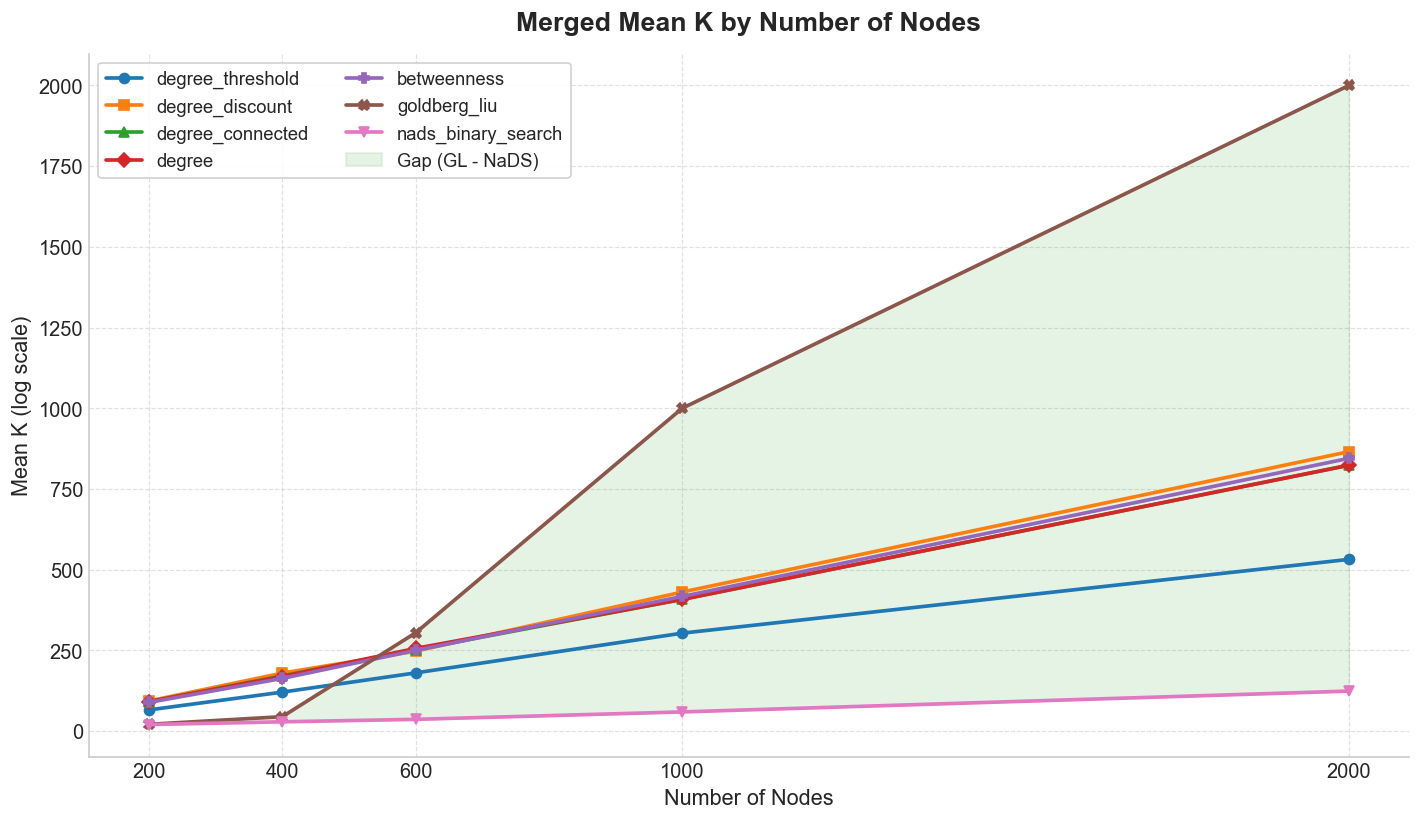

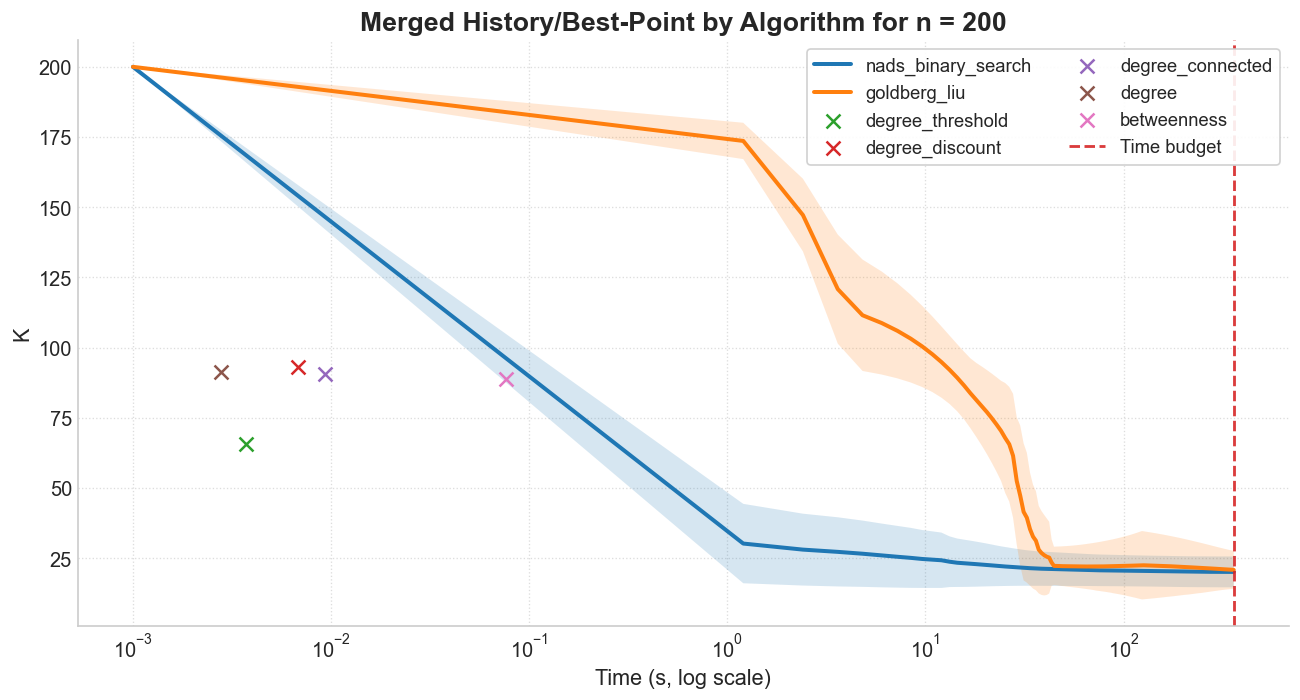

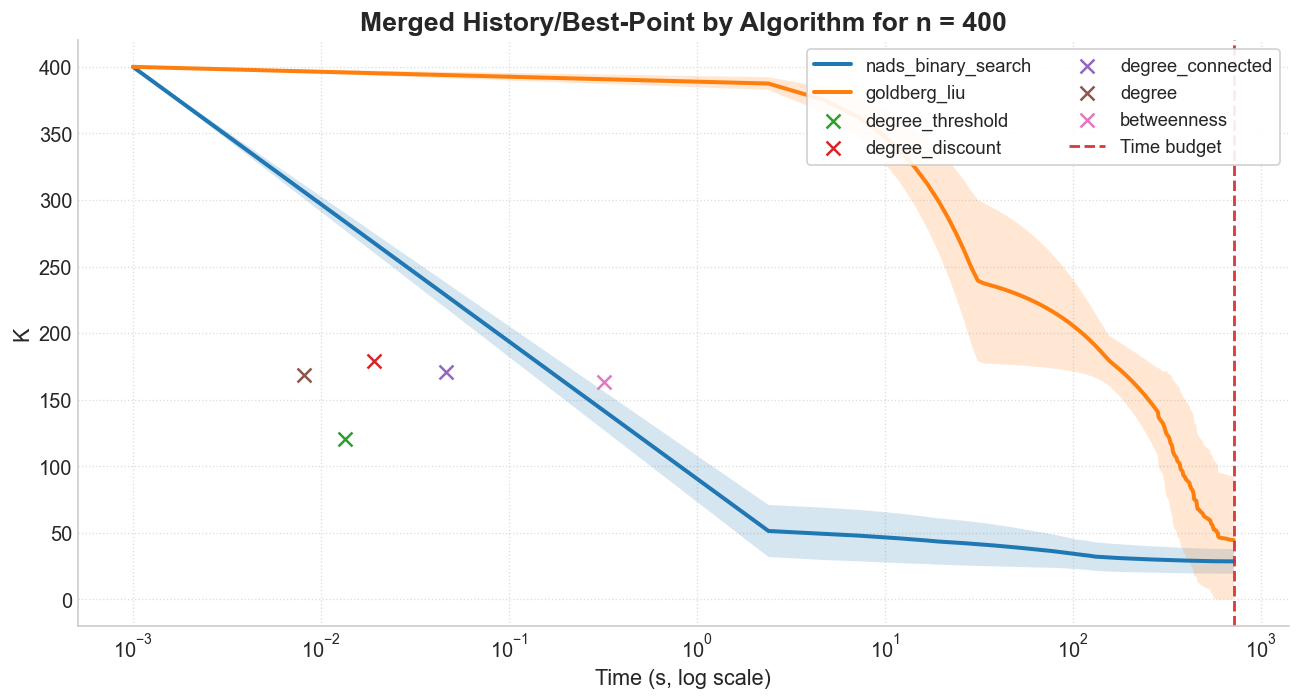

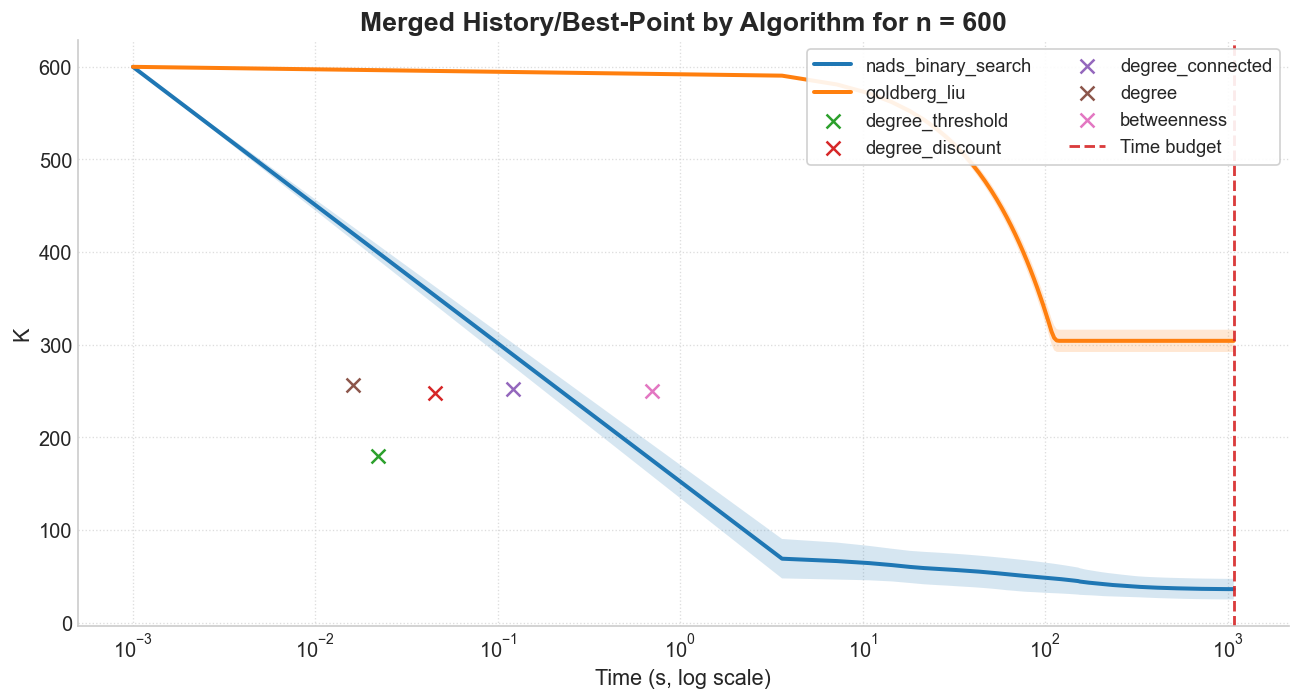

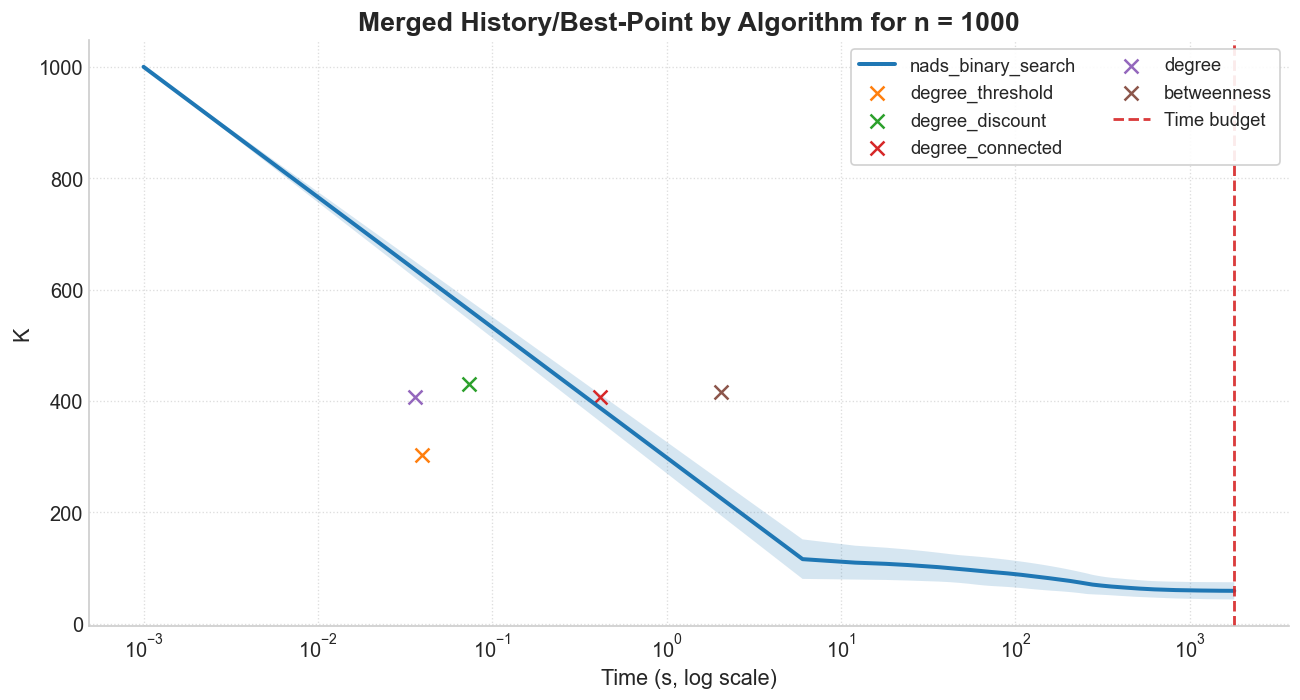

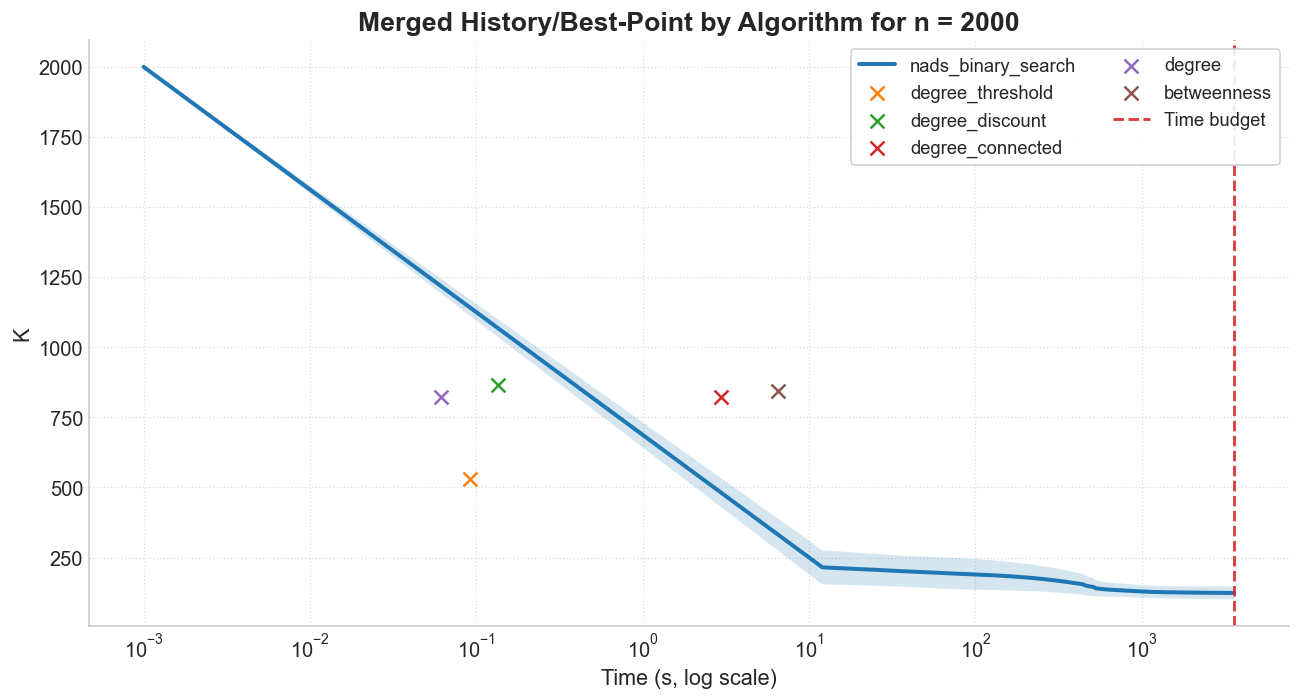

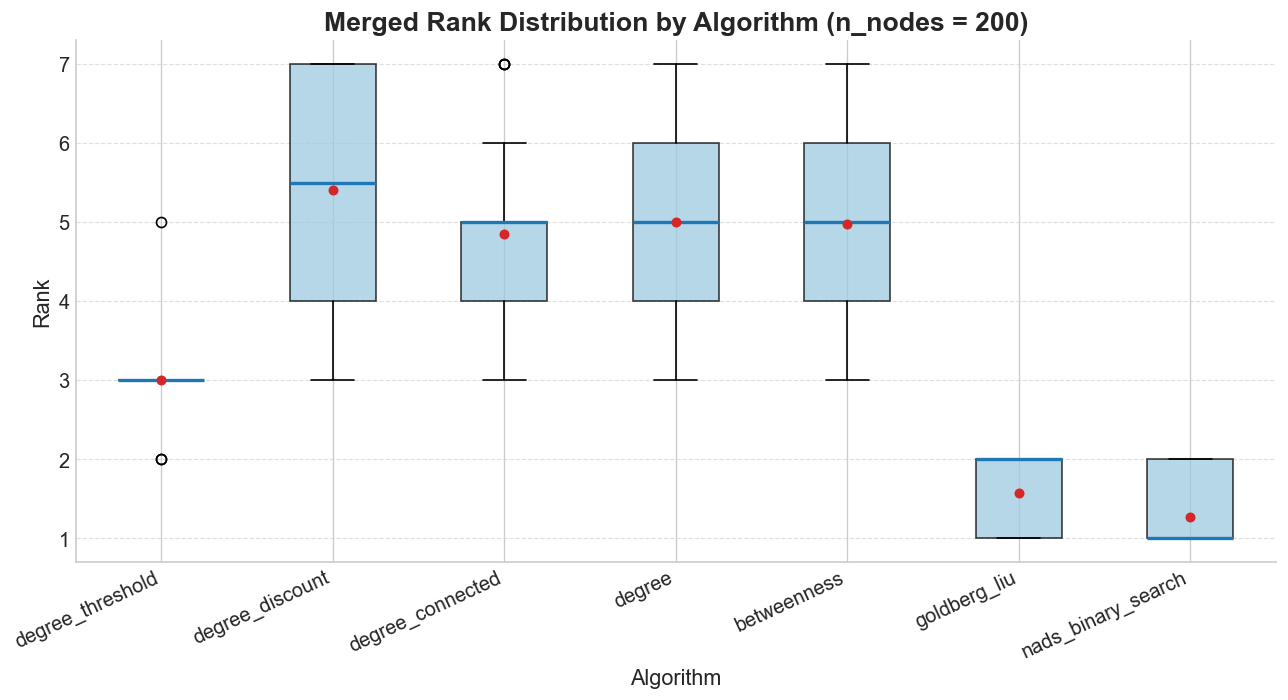

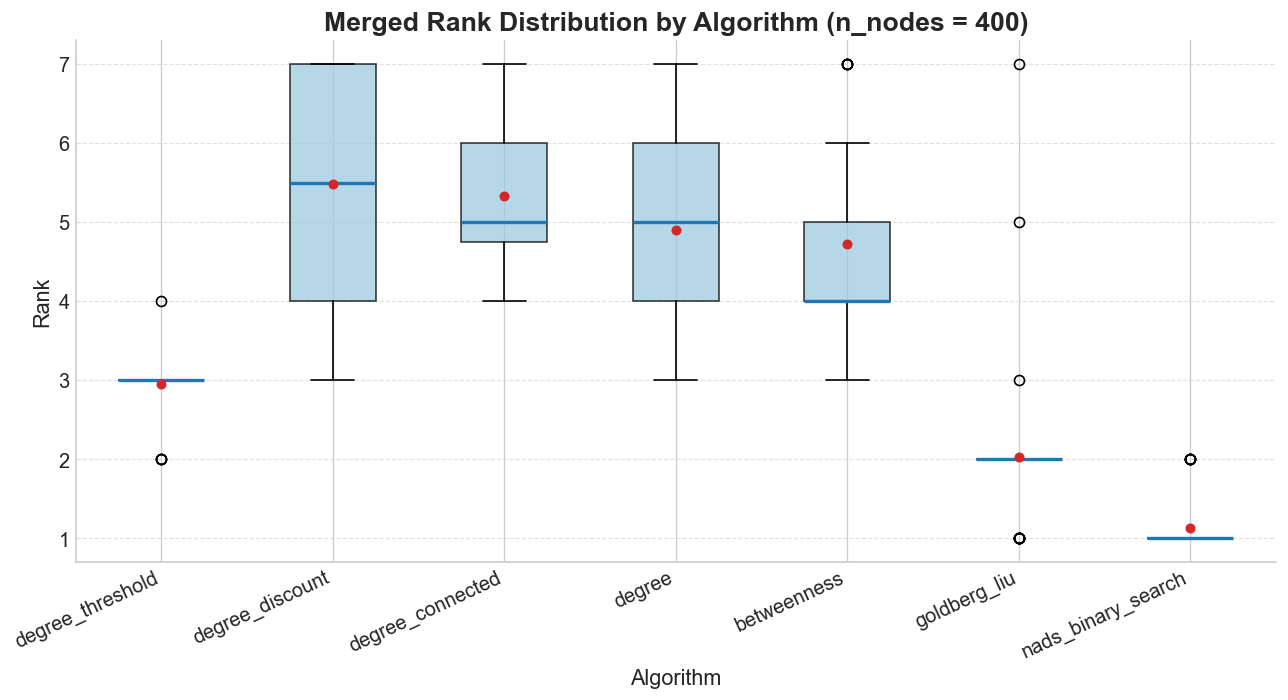

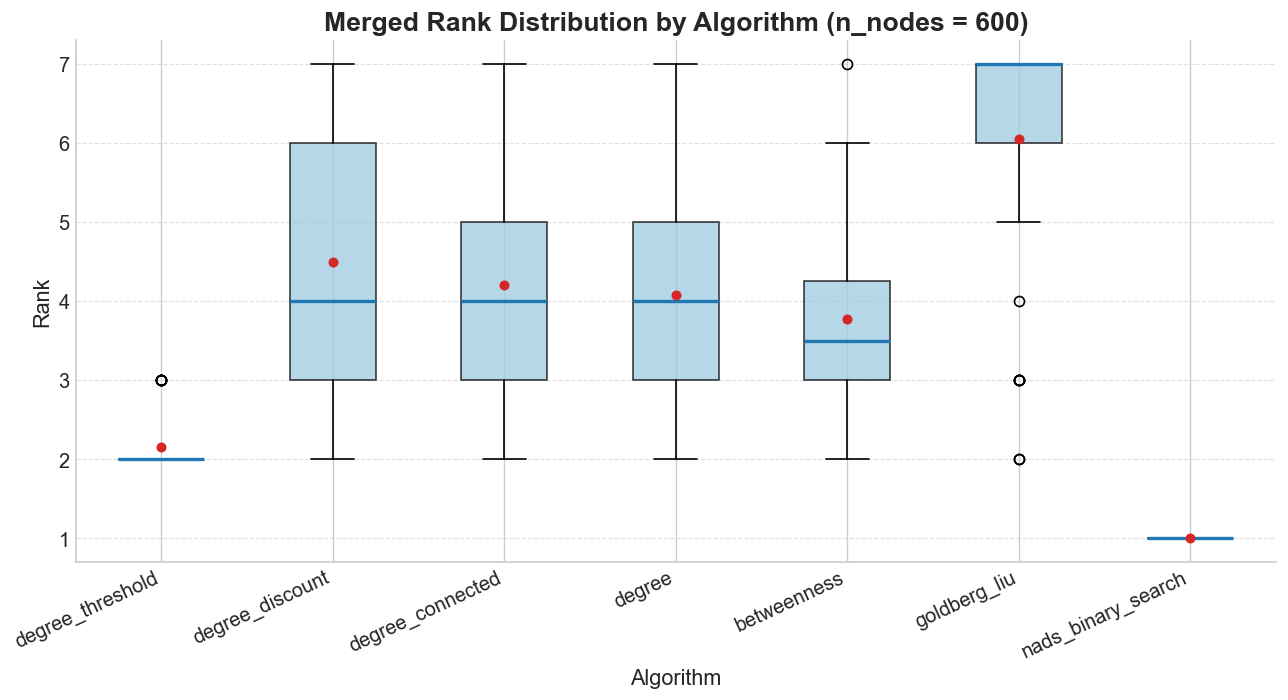

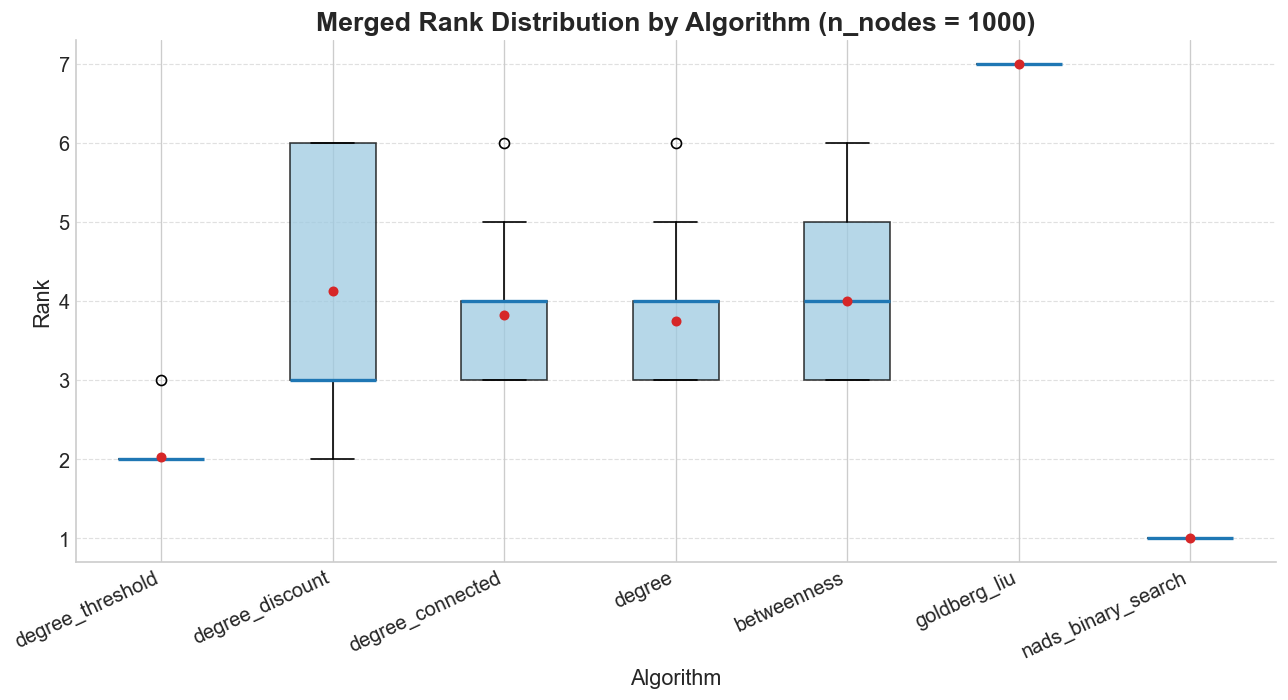

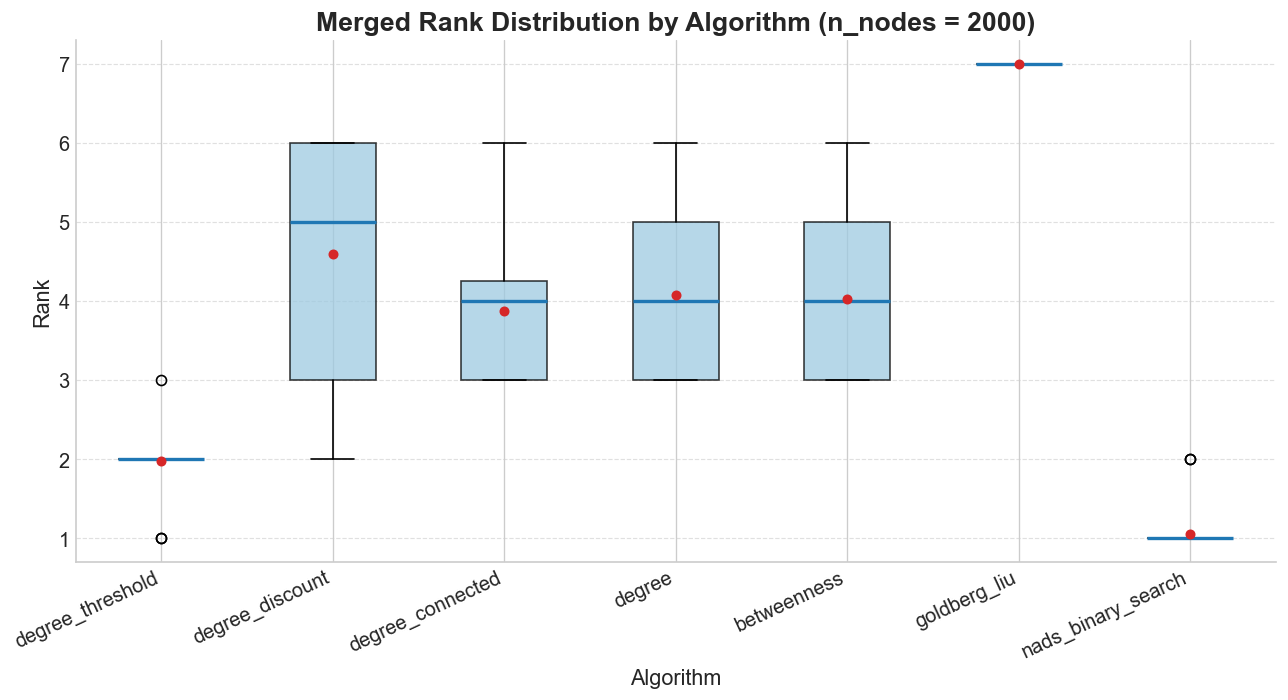

In [16]:
# Merged plots: heuristics (connected=0) + exact NaDS/Goldberg-Liu
heur_file = (
    project_root
    / "experiments"
    / "technology diffusion"
    / "technology_diffusion_results_heuristics__seeds-1-2-3-7-13-17-42-53-99-101__connected-0.csv"
)

if not heur_file.exists():
    raise FileNotFoundError(f"Heuristics results file not found: {heur_file}")

df_results_heur = pd.read_csv(heur_file)

for col in ["n_nodes", "c", "seed", "total_time", "K"]:
    if col in df_results_heur.columns:
        df_results_heur[col] = pd.to_numeric(df_results_heur[col], errors="coerce")

if "df_results" not in globals():
    raise ValueError("Run previous cells first: df_results (exact results) is required.")

df_exact_curves = df_results[df_results["algorithm"].isin(["nads_binary_search", "goldberg_liu"])].copy()
df_results_merged = pd.concat([df_results_heur, df_exact_curves], ignore_index=True, sort=False)

for col in ["n_nodes", "c", "seed", "total_time", "K"]:
    if col in df_results_merged.columns:
        df_results_merged[col] = pd.to_numeric(df_results_merged[col], errors="coerce")

print(
    f"Loaded heuristics rows: {len(df_results_heur)} | "
    f"exact NaDS/GL rows: {len(df_exact_curves)} | "
    f"merged rows: {len(df_results_merged)}"
)
display(df_results_merged.head())

algorithm_order_merged = [
    "degree_threshold",
    "degree_discount",
    "degree_connected",
    "degree",
    "betweenness",
    "goldberg_liu",
    "nads_binary_search",
]

# ---------- Plot 1: Mean K by Number of Nodes ----------
plot_df_m = (
    df_results_merged.groupby(["n_nodes", "algorithm"], as_index=False)
    .agg(mean_K=("K", "mean"), mean_total_time=("total_time", "mean"))
    .sort_values(["n_nodes", "algorithm"])
)

pivot_k_m = plot_df_m.pivot(index="n_nodes", columns="algorithm", values="mean_K").sort_index()
available_algorithms_m = [a for a in algorithm_order_merged if a in pivot_k_m.columns]

if not available_algorithms_m:
    raise ValueError("No expected algorithms found in merged dataframe.")

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

markers = ["o", "s", "^", "D", "P", "X", "v", "<"]
fallback_gl = pd.Series(pivot_k_m.index, index=pivot_k_m.index, dtype=float)

for i, alg in enumerate(available_algorithms_m):
    series = pivot_k_m[alg]
    if alg == "goldberg_liu":
        series = series.fillna(fallback_gl)

    ax.plot(
        pivot_k_m.index,
        series,
        marker=markers[i % len(markers)],
        linewidth=2.2,
        label=alg,
    )

if "goldberg_liu" in pivot_k_m.columns and "nads_binary_search" in pivot_k_m.columns:
    nads_series = pivot_k_m["nads_binary_search"]
    gl_series = pivot_k_m["goldberg_liu"].fillna(fallback_gl)
    ax.fill_between(
        pivot_k_m.index,
        nads_series,
        gl_series,
        where=(gl_series >= nads_series),
        interpolate=True,
        color="#2ca02c",
        alpha=0.12,
        label="Gap (GL - NaDS)",
    )

ax.set_title("Merged Mean K by Number of Nodes", pad=14, weight="bold")
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Mean K (log scale)")
# ax.set_yscale("log")
ax.set_xticks(pivot_k_m.index.to_list())
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, framealpha=0.9, ncols=2, loc="best")

fig.tight_layout()
if save:
    fig.savefig(
        figures_dir / "merged_mean_k_by_nodes_connected_0_plus_exact_curves.png",
        dpi=220,
        bbox_inches="tight",
    )
plt.show()

# ---------- Plot 2: History/Best-Point by Algorithm for each n ----------
# Requires parse_history, mean_std_curve, best_k_time_from_history defined in previous cell.
n_values_m = sorted(df_results_merged["n_nodes"].dropna().unique())
curve_algorithms_m = [a for a in ["nads_binary_search", "goldberg_liu"] if a in available_algorithms_m]
point_algorithms_m = [a for a in available_algorithms_m if a not in set(curve_algorithms_m) and a != "high_thetas"]

for n in n_values_m:
    df_n = df_results_merged[df_results_merged["n_nodes"] == n].copy()
    budget_s = (n / 100) * 180
    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

    plotted = 0

    for alg in curve_algorithms_m:
        histories = df_n.loc[df_n["algorithm"] == alg, "history"].tolist()
        curve = mean_std_curve(histories, t_end=budget_s)
        if curve is None:
            continue
        t_alg, y_mean, y_std = curve
        t_plot = np.maximum(t_alg, 1e-3)
        ax.plot(t_plot, y_mean, linewidth=2.4, label=alg)
        if show_std_band:
            ax.fill_between(
                t_plot,
                np.maximum(y_mean - y_std, 1e-9),
                y_mean + y_std,
                alpha=0.18,
            )
        plotted += 1

    for alg in point_algorithms_m:
        df_alg = df_n[df_n["algorithm"] == alg].copy()
        if df_alg.empty:
            continue

        best_points = []
        for _, row in df_alg.iterrows():
            point = best_k_time_from_history(row.get("history"))
            if point is None:
                k_fallback = pd.to_numeric(row.get("K"), errors="coerce")
                t_fallback = pd.to_numeric(row.get("total_time"), errors="coerce")
                if pd.notna(k_fallback) and pd.notna(t_fallback):
                    point = (float(k_fallback), float(t_fallback))
            if point is not None:
                best_points.append(point)

        if not best_points:
            continue

        mean_best_k = float(np.mean([p[0] for p in best_points]))
        mean_time_to_best = float(np.mean([p[1] for p in best_points]))

        x_point = max(mean_time_to_best, 1e-3)
        y_point = mean_best_k
        ax.scatter(x_point, y_point, s=70, marker="x", label=f"{alg}")
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        continue

    ax.axvline(
        budget_s,
        color="#d62728",
        linestyle="--",
        linewidth=1.7,
        alpha=0.9,
        label="Time budget",
    )

    ax.set_xscale("log")
    ax.set_title(f"Merged History/Best-Point by Algorithm for n = {int(n)}", weight="bold")
    ax.set_xlabel("Time (s, log scale)")
    ax.set_ylabel("K")
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=True, framealpha=0.9, ncols=2)

    fig.tight_layout()
    if save:
        fig.savefig(
            figures_dir / f"merged_history_n_{int(n)}_connected_0_plus_exact_curves.png",
            dpi=220,
            bbox_inches="tight",
        )
    plt.show()

# ---------- Plot 3: Rank distribution by algorithm for each n ----------
candidate_dims = ["n_nodes", "c", "seed"]
instance_keys = [col for col in candidate_dims if col in df_results_merged.columns]

if "algorithm" not in df_results_merged.columns or "K" not in df_results_merged.columns:
    raise ValueError("df_results_merged must contain at least 'algorithm' and 'K' columns.")
if "n_nodes" not in df_results_merged.columns:
    raise ValueError("df_results_merged must contain 'n_nodes' for this plot.")
if not instance_keys:
    raise ValueError("At least one of ['n_nodes', 'c', 'seed'] must be present in df_results_merged.")

required_cols = instance_keys + ["algorithm"]
rank_source = df_results_merged.dropna(subset=required_cols).copy()
rank_source = rank_source[rank_source["algorithm"] != "high_thetas"].copy()

rank_algorithms = [
    a for a in algorithm_order_merged
    if a in rank_source["algorithm"].unique() and a != "high_thetas"
]
if not rank_algorithms:
    rank_algorithms = sorted(rank_source["algorithm"].dropna().unique())

instances = rank_source[instance_keys].drop_duplicates().copy()
instances["_k"] = 1
algorithms_df = pd.DataFrame({"algorithm": rank_algorithms, "_k": 1})

rank_complete = instances.merge(algorithms_df, on="_k", how="inner").drop(columns=["_k"])
k_values = rank_source[instance_keys + ["algorithm", "K"]].copy()
rank_complete = rank_complete.merge(k_values, on=instance_keys + ["algorithm"], how="left")

rank_complete["K_for_rank"] = rank_complete["K"].fillna(np.inf)
rank_complete["rank_in_instance"] = (
    rank_complete.groupby(instance_keys)["K_for_rank"]
    .rank(method="min", ascending=True)
    .astype(int)
)

for n in sorted(rank_complete["n_nodes"].dropna().unique()):
    df_n = rank_complete[rank_complete["n_nodes"] == n].copy()
    if df_n.empty:
        continue

    box_data = [
        df_n.loc[df_n["algorithm"] == alg, "rank_in_instance"].dropna().to_numpy()
        for alg in rank_algorithms
    ]

    if all(len(arr) == 0 for arr in box_data):
        continue

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    bp = ax.boxplot(
        box_data,
        tick_labels=rank_algorithms,
        patch_artist=True,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "#d62728", "markeredgecolor": "#d62728", "markersize": 5},
    )

    for patch in bp["boxes"]:
        patch.set_facecolor("#9ecae1")
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#1f77b4")
        median.set_linewidth(2.0)

    ax.set_title(f"Merged Rank Distribution by Algorithm (n_nodes = {int(n)})", weight="bold")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Rank")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=25, ha="right")

    fig.tight_layout()
    if save:
        fig.savefig(
            figures_dir / f"merged_rank_boxplot_n_{int(n)}_connected_0_plus_exact_curves.png",
            dpi=220,
            bbox_inches="tight",
        )
    plt.show()